In [1]:
import polars as pl
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, AutoMinorLocator
from scipy import stats

def set_font_size(ax, font_size):
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontsize(font_size)

TRANSFER_DATASET = "data/erc1155_transfers.parquet"
NULL_ADDRESS = "0x0000000000000000000000000000000000000000"

In [2]:
def filter_transfers(df):
    return (df.filter(~(pl.col('operator').is_null() | pl.col('from').is_null() | pl.col('to').is_null()))
            .filter(~(pl.col('token_ids').is_null()) & (pl.col('token_ids').list.len() > 0))
            .filter(~(pl.col('amounts').is_null()) & (pl.col('amounts').list.len() > 0))
            .filter(pl.col('token_ids').list.len() == pl.col('amounts').list.len()))

df = pl.read_parquet(TRANSFER_DATASET)
df = filter_transfers(df)
df

address,transaction_index,log_index,transaction_hash,block_number,block_timestamp,type,operator,from,to,token_ids,amounts
str,i64,i64,str,i64,str,str,str,str,str,list[str],list[str]
"""0xd0e4847359ae76c2786d242e5f45…",40,32,"""0x223600ba642f4dc6644e5eb4b0a0…",6930510,"""2018-12-22 04:21:31""","""SINGLE""","""0x6e8a8a0de641161b306cd548710c…","""0x0000000000000000000000000000…","""0x463def03f98b328a75051ee5ebe9…","[""32""]","[""100000000""]"
"""0xd0e4847359ae76c2786d242e5f45…",53,64,"""0x1b839bfeb716c358f367787e77b9…",6930534,"""2018-12-22 04:28:13""","""SINGLE""","""0x6e8a8a0de641161b306cd548710c…","""0x0000000000000000000000000000…","""0x463def03f98b328a75051ee5ebe9…","[""32""]","[""20000000""]"
"""0xd0e4847359ae76c2786d242e5f45…",87,48,"""0x7cf68091cfd5ca00ee9e85a49453…",6930550,"""2018-12-22 04:33:16""","""SINGLE""","""0x8ee1dae56bb5dbc071973618e562…","""0x0000000000000000000000000000…","""0x463def03f98b328a75051ee5ebe9…","[""19""]","[""2270967""]"
"""0xd0e4847359ae76c2786d242e5f45…",87,52,"""0x7cf68091cfd5ca00ee9e85a49453…",6930550,"""2018-12-22 04:33:16""","""SINGLE""","""0x8ee1dae56bb5dbc071973618e562…","""0x0000000000000000000000000000…","""0x463def03f98b328a75051ee5ebe9…","[""32""]","[""10000000""]"
"""0xd0e4847359ae76c2786d242e5f45…",108,57,"""0xb1621b9c77d881ae013cf987cb03…",6930586,"""2018-12-22 04:43:09""","""SINGLE""","""0x6e8a8a0de641161b306cd548710c…","""0x0000000000000000000000000000…","""0x463def03f98b328a75051ee5ebe9…","[""32""]","[""20000000""]"
…,…,…,…,…,…,…,…,…,…,…,…
"""0x62613aa9594d0116b5ca23acd37d…",49,140,"""0x799230a6b903546c01e7559ebac7…",21525888,"""2024-12-31 23:59:35""","""SINGLE""","""0x000000000000f10286d9c1c5d463…","""0x0000000000000000000000000000…","""0x681e32025dfe9d64a83285803360…","[""1""]","[""2""]"
"""0x614577036f0a024dbc1c88ba616b…",120,463,"""0xa41accb830572df56352dc75e208…",21525888,"""2024-12-31 23:59:35""","""SINGLE""","""0x31ba74d3bcaf1b7a176a6cfd6c19…","""0x31ba74d3bcaf1b7a176a6cfd6c19…","""0xf081470f5c6fbccf48cc4e5b82dd…","[""0""]","[""34259325914795663134""]"
"""0x614577036f0a024dbc1c88ba616b…",120,468,"""0xa41accb830572df56352dc75e208…",21525888,"""2024-12-31 23:59:35""","""SINGLE""","""0xf081470f5c6fbccf48cc4e5b82dd…","""0xf081470f5c6fbccf48cc4e5b82dd…","""0xbdd3b040bca2ab6934cbf2ef42bf…","[""0""]","[""34259325914795663134""]"


In [3]:
num_events = len(df)
num_single = len(df.filter(pl.col('type') == 'SINGLE'))
num_batch = len(df.filter(pl.col('type') == 'BATCH'))
num_contracts = df['address'].n_unique()
num_tokens = df.select('address', 'token_ids').explode('token_ids').n_unique()
print(f'N. of events:\t\t\t{num_events}')
print(f'N. of TransferSingle events:\t{num_single}')
print(f'N. of TransferBatch events:\t{num_batch}')
print(f'N. of contracts:\t\t{num_contracts}')
print(f'N. of tokens:\t\t\t{num_tokens}')

N. of events:			64252168
N. of TransferSingle events:	62603221
N. of TransferBatch events:	1648947
N. of contracts:		78526
N. of tokens:			8680312


This will print the number of transfers induced by TransferBatch events.

In [4]:
len(df.filter(pl.col('type') == 'BATCH').select('address', 'token_ids').explode('token_ids'))

6126787

In [7]:
tdf = df.explode(['token_ids', 'amounts'])
# Remove all transfers originating from the 0x0 address (i.e., mint) and those directed to 0x0 (i.e., burn).
# Filter also all self-transfers (i.e., those where sender and receiver coincide).
tdf = tdf.filter((pl.col('from') != NULL_ADDRESS) & (pl.col('to') != NULL_ADDRESS) & (pl.col('from') != pl.col('to')))
len(tdf)

53119907

# Transfer analysis

In [3]:
tdf = df.explode(['token_ids', 'amounts'])
tdf.head()

address,transaction_index,log_index,transaction_hash,block_number,block_timestamp,type,operator,from,to,token_ids,amounts
str,i64,i64,str,i64,str,str,str,str,str,str,str
"""0xd0e4847359ae76c2786d242e5f45…",40,32,"""0x223600ba642f4dc6644e5eb4b0a0…",6930510,"""2018-12-22 04:21:31""","""SINGLE""","""0x6e8a8a0de641161b306cd548710c…","""0x0000000000000000000000000000…","""0x463def03f98b328a75051ee5ebe9…","""32""","""100000000"""
"""0xd0e4847359ae76c2786d242e5f45…",53,64,"""0x1b839bfeb716c358f367787e77b9…",6930534,"""2018-12-22 04:28:13""","""SINGLE""","""0x6e8a8a0de641161b306cd548710c…","""0x0000000000000000000000000000…","""0x463def03f98b328a75051ee5ebe9…","""32""","""20000000"""
"""0xd0e4847359ae76c2786d242e5f45…",87,48,"""0x7cf68091cfd5ca00ee9e85a49453…",6930550,"""2018-12-22 04:33:16""","""SINGLE""","""0x8ee1dae56bb5dbc071973618e562…","""0x0000000000000000000000000000…","""0x463def03f98b328a75051ee5ebe9…","""19""","""2270967"""
"""0xd0e4847359ae76c2786d242e5f45…",87,52,"""0x7cf68091cfd5ca00ee9e85a49453…",6930550,"""2018-12-22 04:33:16""","""SINGLE""","""0x8ee1dae56bb5dbc071973618e562…","""0x0000000000000000000000000000…","""0x463def03f98b328a75051ee5ebe9…","""32""","""10000000"""
"""0xd0e4847359ae76c2786d242e5f45…",108,57,"""0xb1621b9c77d881ae013cf987cb03…",6930586,"""2018-12-22 04:43:09""","""SINGLE""","""0x6e8a8a0de641161b306cd548710c…","""0x0000000000000000000000000000…","""0x463def03f98b328a75051ee5ebe9…","""32""","""20000000"""


In [5]:
transfers_by_contract = tdf['address'].value_counts(name='transfers')
transfers_by_contract['transfers'].value_counts(name='contracts').sort(by='transfers')

transfers,contracts
u32,u32
1,16701
2,8055
3,4996
4,3940
5,2507
…,…
1075841,1
1172499,1
1240388,1


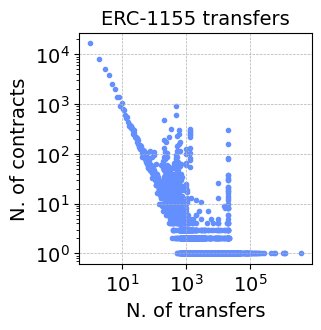

In [6]:
transfers_by_contract = tdf['address'].value_counts(name='transfers')
data = transfers_by_contract['transfers'].value_counts(name='contracts')
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-1155 transfers')
ax.set_xlabel('N. of transfers')
ax.set_ylabel('N. of contracts')
ax.set_xscale('log')
ax.set_yscale('log')
ax.scatter(data['transfers'], data['contracts'], color='#648fff', marker='.', rasterized=True)
ax.grid(which='major', linestyle='--', linewidth=0.5)
set_font_size(ax, 14)
plt.savefig("figures/transfers-contract.pdf", format='pdf', bbox_inches='tight')
plt.show()

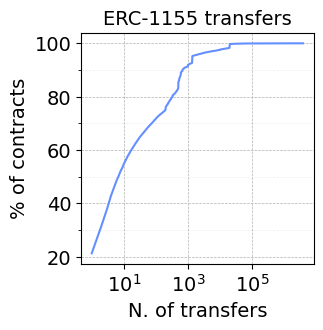

In [5]:
transfers_by_contract = tdf['address'].value_counts(name='transfers')
data = transfers_by_contract['transfers'].value_counts(name='contracts').sort('transfers')
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-1155 transfers')
ax.set_xlabel('N. of transfers')
ax.set_ylabel('% of contracts')
ax.set_xscale('log')
ax.plot(data['transfers'], (np.cumsum(data['contracts']) * 100) / data['contracts'].sum(), color='#648fff')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
set_font_size(ax, 14)
plt.savefig("figures/transfers-contract-cumul.pdf", format='pdf', bbox_inches='tight')
plt.show()

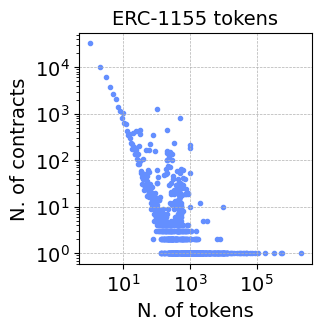

In [7]:
tokens_by_contract = tdf.group_by('address').agg(pl.col('token_ids').n_unique().alias('tokens'))
data = tokens_by_contract['tokens'].value_counts(name='contracts')
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-1155 tokens')
ax.set_xlabel('N. of tokens')
ax.set_ylabel('N. of contracts')
ax.set_xscale('log')
ax.set_yscale('log')
ax.scatter(data['tokens'], data['contracts'], color='#648fff', marker='.', rasterized=True)
ax.grid(which='major', linestyle='--', linewidth=0.5)
set_font_size(ax, 14)
plt.savefig("figures/tokens-contract.pdf", format='pdf', bbox_inches='tight')
plt.show()

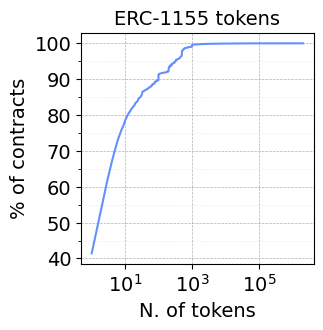

In [10]:
tokens_by_contract = tdf.group_by('address').agg(pl.col('token_ids').n_unique().alias('tokens'))
data = tokens_by_contract['tokens'].value_counts(name='contracts').sort('tokens')
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-1155 tokens')
ax.set_xlabel('N. of tokens')
ax.set_ylabel('% of contracts')
ax.set_xscale('log')
ax.plot(data['tokens'], (np.cumsum(data['contracts']) * 100) / data['contracts'].sum(), color='#648fff')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
set_font_size(ax, 14)
plt.savefig("figures/tokens-contract-cumul.pdf", format='pdf', bbox_inches='tight')
plt.show()